### Credit Risk Scoring - Decision Trees & Ensemble Methods

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score

In [3]:
df = pd.read_csv('CreditScoring.csv')

In [4]:
df.head().T

,0,1,2,3,4
Status,1,1,2,1,1
Seniority,9,17,10,0,0
Home,1,1,2,1,1
Time,60,60,36,60,36
Age,30,58,46,24,26
Marital,2,3,2,1,1
Records,1,1,2,1,1
Job,3,1,3,1,1
Expenses,73,48,90,63,46
Income,129,131,200,182,107


In [5]:
df.columns = df.columns.str.lower()

In [6]:
df.head().T

,0,1,2,3,4
status,1,1,2,1,1
seniority,9,17,10,0,0
home,1,1,2,1,1
time,60,60,36,60,36
age,30,58,46,24,26
marital,2,3,2,1,1
records,1,1,2,1,1
job,3,1,3,1,1
expenses,73,48,90,63,46
income,129,131,200,182,107


In [7]:
df.status = df.status.map({0:'unknown', 1:'ok', 2:'default'})
df.home = df.home.map({0:'unknown', 1:'rent', 2:'owner', 3:'private', 4:'ignore', 5:'parent', 6:'other'})
df.marital = df.marital.map({0:'unknown', 1:'single', 2:'married', 3:'widow', 4:'separated', 5:'divorced'})
df.records = df.records.map({0:'unknown', 1:'no', 2:'yes'})
df.job = df.job.map({0:'unknown', 1:'fixed', 2:'partime', 3:'freelance', 4:'other'})

In [8]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129,0,0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131,0,0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200,3000,0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182,2500,0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107,0,0,310,910


In [9]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,763317.0,1060341.0,404382.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,8703625.0,10217569.0,6344253.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3500.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,166.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,99999999.0,99999999.0,99999999.0,5000.0,11140.0


In [10]:
for i in ['income', 'assets', 'debt']:
    df[i] = df[i].replace(to_replace=99999999, value = np.nan)

In [11]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4421.0,4408.0,4437.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,131.0,5403.0,343.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,86.0,11573.0,1246.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3000.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,165.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,959.0,300000.0,30000.0,5000.0,11140.0


In [12]:
df.status.value_counts()

status
ok         3200
default    1254
unknown       1
Name: count, dtype: int64

In [13]:
df = df[df.status != 'unknown'].reset_index(drop=True) # Removing 'unknown' records from status
df

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129.0,0.0,0.0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131.0,0.0,0.0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200.0,3000.0,0.0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182.0,2500.0,0.0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107.0,0.0,0.0,310,910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4449,default,1,rent,60,39,married,no,fixed,69,92.0,0.0,0.0,900,1020
4450,ok,22,owner,60,46,married,no,fixed,60,75.0,3000.0,600.0,950,1263
4451,default,0,owner,24,37,married,no,partime,60,90.0,3500.0,0.0,500,963
4452,ok,0,rent,48,23,single,no,freelance,49,140.0,0.0,0.0,550,550


In [14]:
df_fulltrain, df_test = train_test_split(df, test_size = 0.2, random_state = 11)
df_train, df_val = train_test_split(df_fulltrain, test_size = 0.25, random_state = 11)

In [15]:
df_train = df_train.reset_index(drop=True)  # Resetting index for our dataframe 
df_test = df_test.reset_index(drop=True)
df_test = df_val.reset_index(drop=True)

In [16]:
y_train = (df_train.status == 'default').astype('int').values  # Convert status from categorical to numerical 0,1
y_test = (df_test.status == 'default').astype('int').values   # Encoding 'default' values as True and then as 0,1
y_val = (df_val.status == 'default').astype('int').values

In [17]:
del df_train['status']  # Removing the 'default' variables from our dataframe -> it removes column 'status'
del df_test['status']
del df_val['status']

#### Decision Trees
Training our model

In [18]:
def risk_score(client):             # Using conditional statement to assess the risk score of a client
    if client['records']=='yes':
        if client['job']=='partime':
            return 'default'
        else:
            return 'ok'
    else:
        if client['assets']>7000:
            return 'ok'
        else:
            return 'default'

In [19]:
client_k = df_train.iloc[100].to_dict()
risk_score(client_k)

'default'

In [20]:
train_dicts = df_train.to_dict(orient = 'records')
train_dicts[:1]

[{'seniority': 10,
  'home': 'owner',
  'time': 36,
  'age': 36,
  'marital': 'married',
  'records': 'no',
  'job': 'freelance',
  'expenses': 75,
  'income': 0.0,
  'assets': 10000.0,
  'debt': 0.0,
  'amount': 1000,
  'price': 1400}]

In [21]:
dv = DictVectorizer(sparse=False)       # Training our dict_vectorizer
X_train = dv.fit_transform(train_dicts)

In [22]:
dt = DecisionTreeClassifier() 
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [23]:
val_dicts = df_val.to_dict(orient = 'records')
X_val = dv.transform(val_dicts)

In [24]:
y_pred = dt.predict_proba(X_val)[:,1]

In [25]:
roc_auc_score(y_val, y_pred)  # AUC score of our validation set

np.float64(0.6505503620643724)

AUC score of 67% of our validation set is not impressive

In [26]:
y_pred = dt.predict_proba(X_train)[:,1]
roc_auc_score(y_train, y_pred)

np.float64(1.0)

The AUC score of our training set is 100% which suggests an overfitting model

#### Adjusting the depth of our tree to see how the model peforms

In [27]:
dt = DecisionTreeClassifier(max_depth=3) # 5->76,84
dt.fit(X_train, y_train)

val_dicts = df_val.to_dict(orient = 'records')
X_val = dv.transform(val_dicts)

y_pred = dt.predict_proba(X_val)[:,1]
auc = roc_auc_score(y_val, y_pred)
print('Validation_set auc:', auc)

y_pred = dt.predict_proba(X_train)[:,1]  
auc = roc_auc_score(y_train, y_pred)
print('Training_set auc:', auc)

Validation_set auc: 0.7389079944782155
Training_set auc: 0.7761016984958594


In [28]:
from sklearn.tree import export_text

In [29]:
print(export_text(dt, feature_names= dv.get_feature_names_out()))

|--- records=no <= 0.50
|   |--- seniority <= 6.50
|   |   |--- amount <= 862.50
|   |   |   |--- class: 0
|   |   |--- amount >  862.50
|   |   |   |--- class: 1
|   |--- seniority >  6.50
|   |   |--- income <= 103.50
|   |   |   |--- class: 1
|   |   |--- income >  103.50
|   |   |   |--- class: 0
|--- records=no >  0.50
|   |--- job=partime <= 0.50
|   |   |--- income <= 74.50
|   |   |   |--- class: 0
|   |   |--- income >  74.50
|   |   |   |--- class: 0
|   |--- job=partime >  0.50
|   |   |--- assets <= 8750.00
|   |   |   |--- class: 1
|   |   |--- assets >  8750.00
|   |   |   |--- class: 0



#### Decision Tree Learning Algorithm
Selecting max_depth and mean_samples_leaf

In [30]:
for d in [1,2,3,4,5,6,7,8,9,10,14,15,None]:
    dt = DecisionTreeClassifier(max_depth=d)
    dt.fit(X_train, y_train)
    
    y_pred = dt.predict_proba(X_val)[:,1]
    auc = roc_auc_score(y_val, y_pred)

    print('%4s -> %.3f' % (d, auc))

   1 -> 0.606
   2 -> 0.669
   3 -> 0.739
   4 -> 0.761
   5 -> 0.766
   6 -> 0.747
   7 -> 0.749
   8 -> 0.725
   9 -> 0.720
  10 -> 0.694
  14 -> 0.677
  15 -> 0.665
None -> 0.658


We obtained 4, 5, 6 as the best tree depths

In [31]:
scores =[]

for d in [4,5,6,7,9]:
#for d in range(3,20,2):
    #for s in range(5,100,5):
    for s in [1,5,6,8,9,10,15,18,80,100,200]:
        dt = DecisionTreeClassifier(max_depth=d, min_samples_leaf=s)
        dt.fit(X_train, y_train)
    
        y_pred = dt.predict_proba(X_val)[:,1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((d, s, auc))

In [32]:
df_scores = pd.DataFrame(scores, columns = ['max_depth', 'min_samples_leaf', 'auc'])

In [33]:
df_scores.sort_values(by = 'auc', ascending=False).head()

,max_depth,min_samples_leaf,auc
50,9,15,0.790209
41,7,80,0.787311
52,9,80,0.787051
39,7,15,0.786279
28,6,15,0.786119


Let's reorganize our table using pivot

In [34]:
df_scores_pivot = df_scores.pivot(index='min_samples_leaf', columns = ['max_depth'], values=['auc'])
df_scores_pivot.head().round(3)

auc                            
max_depth             4      5      6      7      9
min_samples_leaf                                   
1                 0.761  0.766  0.749  0.749  0.720
5                 0.761  0.768  0.764  0.759  0.740
6                 0.761  0.768  0.771  0.765  0.738
8                 0.761  0.767  0.771  0.760  0.745
9                 0.761  0.770  0.780  0.770  0.766

<Axes: xlabel='None-max_depth', ylabel='min_samples_leaf'>

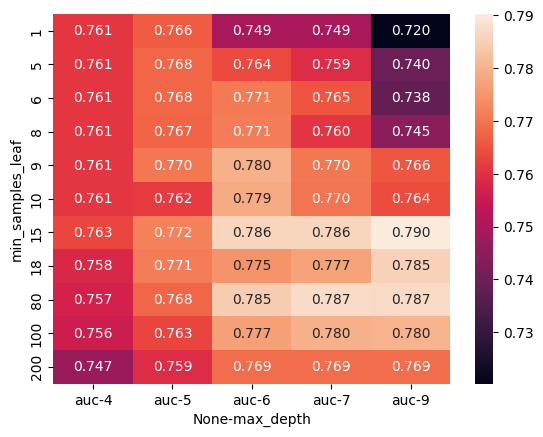

In [35]:
sns.heatmap(df_scores_pivot, annot=True, fmt='.3f')

This method could be sub-optimal since we only chose a few max_depth without exhauting ample possible tree depths

#### Final training of our decision tree
We use the max_depth of 6 and min_samples_leaf of 15 to train our decision tree

In [94]:
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)

In [95]:
y_pred = dt.predict_proba(X_val)[:,1]
roc_auc_score(y_val, y_pred)

np.float64(0.7861125911215519)

#### Ensemble Methods
Random Forest Classifier (RF)

In [38]:
from sklearn.ensemble import RandomForestClassifier

In [39]:
rf = RandomForestClassifier(n_estimators=10, random_state=1)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=1)

In [40]:
y_pred = rf.predict_proba(X_val)[:,1]

In [41]:
roc_auc_score(y_val, y_pred)

np.float64(0.7865424668814027)

In [42]:
scores =[]

for n in range(10,201,10):
    rf = RandomForestClassifier(n_estimators=n, random_state=1)
    rf.fit(X_train, y_train)
    
    y_pred = rf.predict_proba(X_val)[:,1]
    auc = roc_auc_score(y_val, y_pred)

    scores.append((n, auc))

In [43]:
df_scores = pd.DataFrame(scores, columns = ['n_estimators', 'auc'])

In [44]:
df_scores.sort_values(by = 'auc', ascending=False).head()

,n_estimators,auc
17,180,0.820488
18,190,0.819909
19,200,0.819528
14,150,0.819261
11,120,0.819080


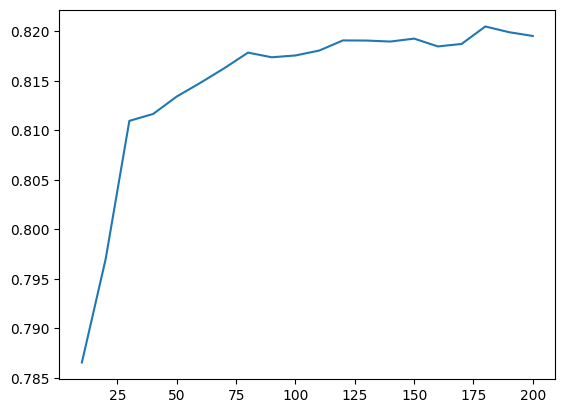

In [45]:
plt.plot(df_scores.n_estimators, df_scores.auc)

Training RF model with a max_depth parameter 

In [46]:
scores =[]

for n in range(10,201,10):
    for d in range(1,10,2):
        
        rf = RandomForestClassifier(n_estimators=n, max_depth = d, random_state=1)
        rf.fit(X_train, y_train)
    
        y_pred = rf.predict_proba(X_val)[:,1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((n, d, auc))

In [47]:
df_scores = pd.DataFrame(scores, columns = ['n_estimators', 'max_depth', 'auc'])

In [48]:
df_scores.sort_values(by = 'auc', ascending=False)

,n_estimators,max_depth,auc
69,140,9,0.825716
94,190,9,0.825498
89,180,9,0.825413
64,130,9,0.825219
99,200,9,0.825219
...,...,...,...
90,190,1,0.780461
5,20,1,0.780261
20,50,1,0.779256
25,60,1,0.778835


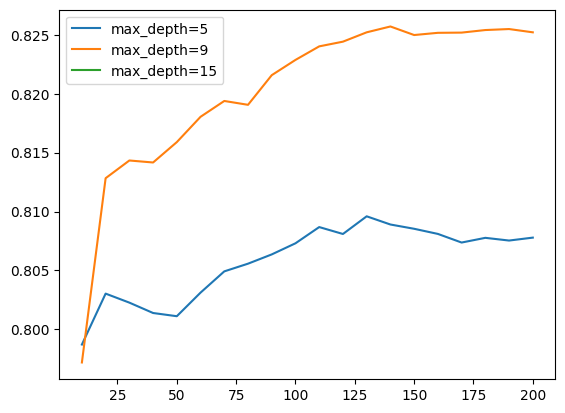

In [49]:
for d in (5, 9, 15):
    df_subset = df_scores[df_scores.max_depth==d]
    plt.plot(df_subset.n_estimators, df_subset.auc, label = 'max_depth=%d' %d)

plt.legend()

A max_depth of 9 is the best 

Training our model with min_sample_leafs

In [50]:
scores =[]

for n in range(10,201,10):
    for s in (1,3,5,10,15):
        
        rf = RandomForestClassifier(n_estimators=n, max_depth = 9, min_samples_leaf=s ,random_state=1)
        rf.fit(X_train, y_train)
    
        y_pred = rf.predict_proba(X_val)[:,1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((n, s, auc))

In [51]:
df_scores = pd.DataFrame(scores, columns = ['n_estimators', 'min_samples_leaf', 'auc'])

In [52]:
df_scores.sort_values(by = 'auc', ascending=False)

,n_estimators,min_samples_leaf,auc
96,200,3,0.827932
71,150,3,0.827913
91,190,3,0.827823
86,180,3,0.827683
76,160,3,0.827641
...,...,...,...
3,10,10,0.811215
7,20,5,0.809656
4,10,15,0.806069
0,10,1,0.797177


min_samples_leaf of 3 gives us the best estimator

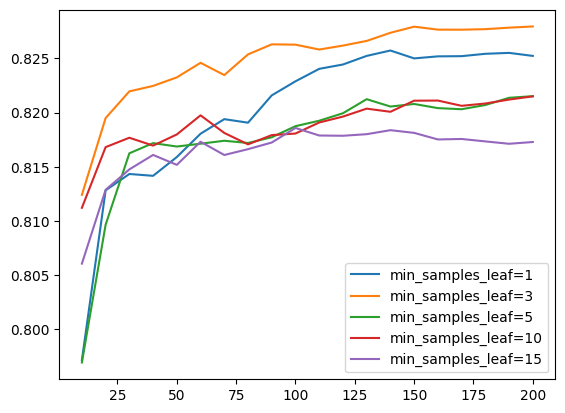

In [53]:
for s in (1,3,5,10,15):
    df_subset = df_scores[df_scores.min_samples_leaf==s]
    plt.plot(df_subset.n_estimators, df_subset.auc, label = 'min_samples_leaf=%d' %s)

plt.legend()

##### Retraining our Random Forests model with the best parameters
max_depth = 9, n_estimators = 180, min_samples_leaf = 3

In [100]:
rf = RandomForestClassifier(n_estimators=180, max_depth = 9, min_samples_leaf=3 ,random_state=1)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=9, min_samples_leaf=3, n_estimators=180,
                       random_state=1)

In [98]:
y_pred = rf.predict_proba(X_val)[:,1]
roc_auc_score(y_val, y_pred)

np.float64(0.8276833934755756)

In [56]:
y_pred = dt.predict_proba(X_train)[:,1]  
roc_auc_score(y_train, y_pred)

np.float64(0.8617810264210468)

#### Gradient Boosting

In [57]:
import xgboost as xgb

In [58]:
features = dv.get_feature_names_out().tolist()
dtrain = xgb.DMatrix(X_train, label = y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label = y_val, feature_names=features)

In [59]:
xgb_params = {'eta': 0.3, 'max_depth': 9, 'min_child_weight':1, 'objective':'binary:logistic', 'nthread':8, 
             'seed': 1, 'verbosity':1,}

model = xgb.train(xgb_params, dtrain, num_boost_round=200)

Testing our model

In [60]:
y_pred = model.predict(dval)

In [61]:
roc_auc_score(y_val, y_pred)

np.float64(0.8023933787023806)

The model shows a considerable performance of with AUC of 80% with default parameters

In [62]:
y_pred = model.predict(dtrain)
roc_auc_score(y_train, y_pred)

np.float64(1.0)

The AUC score of our training set is 100% which suggests an overfitting model

##### We want to monitor the performance of our model during training
After each iteration, we want to evlaute with our validation data

In [63]:
watchlist = [(dtrain, 'train'), (dval, 'val')]

In [64]:
scores = {}

In [65]:
%%capture output

xgb_params = {'eta': 0.3, 'max_depth': 9, 'min_child_weight':1, 'objective':'binary:logistic', 'nthread':8, 
             'eval_metric': 'auc', 'seed': 1, 'verbosity':1,}

model = xgb.train(xgb_params, dtrain, num_boost_round=200, evals = watchlist, verbose_eval = 10)

In [66]:
print(output.stdout)

[0]	train-auc:0.91014	val-auc:0.77331
[10]	train-auc:0.99466	val-auc:0.80782
[20]	train-auc:0.99913	val-auc:0.80668
[30]	train-auc:0.99996	val-auc:0.80683
[40]	train-auc:1.00000	val-auc:0.80911
[50]	train-auc:1.00000	val-auc:0.80830
[60]	train-auc:1.00000	val-auc:0.80370
[70]	train-auc:1.00000	val-auc:0.80409
[80]	train-auc:1.00000	val-auc:0.80352
[90]	train-auc:1.00000	val-auc:0.80331
[100]	train-auc:1.00000	val-auc:0.80414
[110]	train-auc:1.00000	val-auc:0.80445
[120]	train-auc:1.00000	val-auc:0.80437
[130]	train-auc:1.00000	val-auc:0.80306
[140]	train-auc:1.00000	val-auc:0.80344
[150]	train-auc:1.00000	val-auc:0.80345
[160]	train-auc:1.00000	val-auc:0.80334
[170]	train-auc:1.00000	val-auc:0.80394
[180]	train-auc:1.00000	val-auc:0.80403
[190]	train-auc:1.00000	val-auc:0.80268
[199]	train-auc:1.00000	val-auc:0.80239



In [67]:
def parse_xgb_output(out):
    results = []

    for line in output.stdout.strip().split('\n'):
        it_line, train_line, val_line = line.split('\t')

        it = int(it_line.strip('[]'))
        train = float(train_line.split(':')[1])
        val = float(val_line.split(':')[1])

        results.append((it, train, val))
        
    columns = ['num_iter', 'train_auc', 'val_auc']
    df_results = pd.DataFrame(results, columns=columns)
    return df_results

In [68]:
df_score = parse_xgb_output(output)

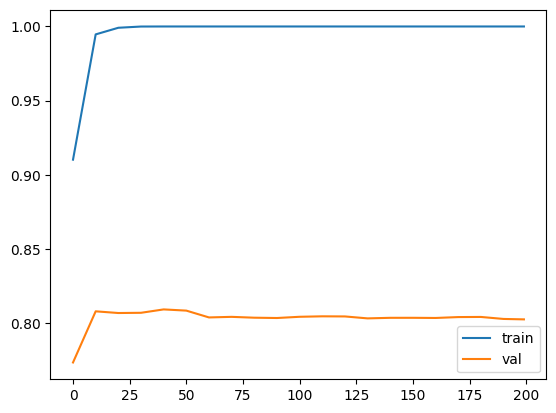

In [69]:
plt.plot(df_score.num_iter, df_score.train_auc, label ='train')
plt.plot(df_score.num_iter, df_score.val_auc, label ='val')
plt.legend()

#### XGBoost Parameter Tuning
Here, we focus on the eta, max_depth & min_child_weight

In [123]:
scores = {}

In [132]:
%%capture output

xgb_params = {'eta': 1.0, 'max_depth': 9, 'min_child_weight':1, 'objective':'binary:logistic', 
                  'eval_metric':'auc', 'nthread':8, 
             'seed': 1, 'verbosity':1,}

model = xgb.train(xgb_params, dtrain, num_boost_round=200, evals = watchlist, verbose_eval = 10)

In [133]:
key = 'eta=%s' % (xgb_params['eta'])
scores[key]= parse_xgb_output(output)
key

'eta=1.0'

In [134]:
scores.keys()

dict_keys(['eta=0.01', 'eta=0.03', 'eta=0.05', 'eta=0.1', 'eta=1.0'])

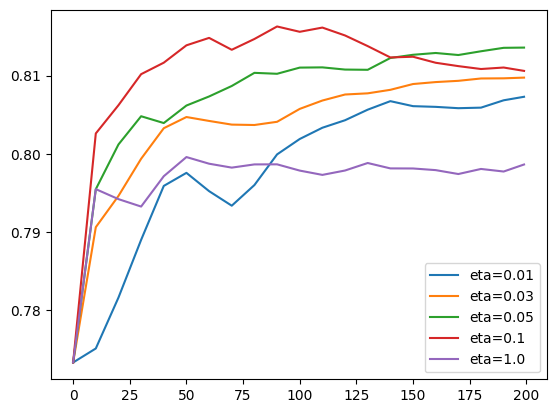

In [135]:
for eta, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label =eta)
plt.legend()

eta of 0.1 is the best

##### Tuning the max_depth parameter

In [136]:
scores = {}

In [137]:
scores.pop('eta=0.01', None) 
scores.pop('eta=0.03', None)
scores.pop('eta=0.05', None)
scores.pop('eta=0.1', None) 
scores.pop('eta=1.0', None)

In [148]:
%%capture output

xgb_params = {'eta': 0.1, 'max_depth': 10, 'min_child_weight':1, 'objective':'binary:logistic', 
                  'eval_metric':'auc', 'nthread':8, 
             'seed': 1, 'verbosity':1,}

model = xgb.train(xgb_params, dtrain, num_boost_round=200, evals = watchlist, verbose_eval = 5)

In [149]:
key = 'max_depth=%s' % (xgb_params['max_depth'])
scores[key]= parse_xgb_output(output)
key

'max_depth=10'

In [150]:
scores.keys()

dict_keys(['max_depth=1', 'max_depth=3', 'max_depth=5', 'max_depth=6', 'max_depth=9', 'max_depth=10'])

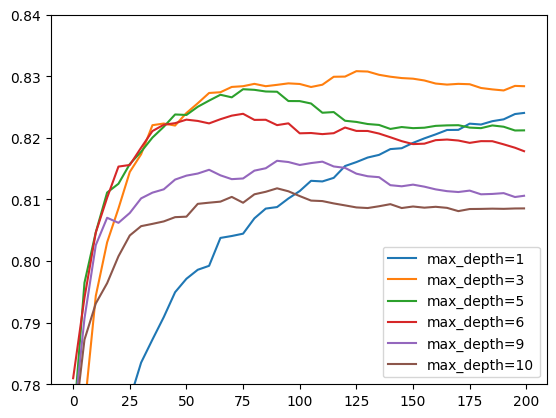

In [151]:
for max_depth, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label =max_depth)
plt.ylim(0.78, 0.84)
plt.legend()

max_depth of 3 gives the best estimation

##### Tuning the min_child_weight parameter

In [152]:
scores = {}

In [153]:
scores.pop('max_depth=1', None) 
scores.pop('max_depth=3', None)
scores.pop('max_depth=5', None) 
scores.pop('max_depth=6', None)
scores.pop('max_depth=9', None) 
scores.pop('max_depth=10', None)

In [162]:
xgb_params = {'eta': 0.1, 'max_depth': 3, 'min_child_weight':30, 'objective':'binary:logistic', 
                  'eval_metric':'auc', 'nthread':8, 
             'seed': 1, 'verbosity':1,}

model = xgb.train(xgb_params, dtrain, num_boost_round=200, evals = watchlist, verbose_eval = 5)

[0]	train-auc:0.76455	val-auc:0.73369
[5]	train-auc:0.82726	val-auc:0.77541
[10]	train-auc:0.84502	val-auc:0.79427
[15]	train-auc:0.85463	val-auc:0.80428
[20]	train-auc:0.86012	val-auc:0.80706
[25]	train-auc:0.86540	val-auc:0.81224
[30]	train-auc:0.87128	val-auc:0.81761
[35]	train-auc:0.87380	val-auc:0.82018
[40]	train-auc:0.87716	val-auc:0.82236
[45]	train-auc:0.87955	val-auc:0.82548
[50]	train-auc:0.88162	val-auc:0.82732
[55]	train-auc:0.88340	val-auc:0.82939
[60]	train-auc:0.88444	val-auc:0.82933
[65]	train-auc:0.88580	val-auc:0.82976
[70]	train-auc:0.88691	val-auc:0.83111
[75]	train-auc:0.88864	val-auc:0.83259
[80]	train-auc:0.88979	val-auc:0.83339
[85]	train-auc:0.89058	val-auc:0.83336
[90]	train-auc:0.89156	val-auc:0.83390
[95]	train-auc:0.89226	val-auc:0.83422
[100]	train-auc:0.89285	val-auc:0.83484
[105]	train-auc:0.89376	val-auc:0.83514
[110]	train-auc:0.89446	val-auc:0.83557
[115]	train-auc:0.89553	val-auc:0.83577
[120]	train-auc:0.89607	val-auc:0.83589
[125]	train-auc:0.8966

In [163]:
key = 'min_child_weight=%s' % (xgb_params['min_child_weight'])
scores[key]= parse_xgb_output(output)
key

'min_child_weight=30'

In [164]:
scores.keys()

dict_keys(['min_child_weight=1', 'min_child_weight=5', 'min_child_weight=10', 'min_child_weight=15', 'min_child_weight=30'])

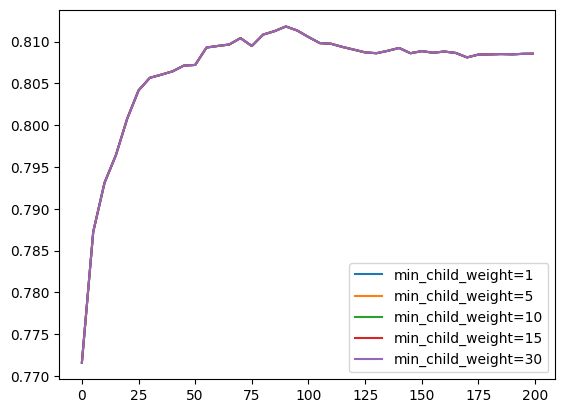

In [165]:
for min_child_weight, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label =min_child_weight)
plt.legend()

#### Final Model Selection 
We use eta = 0.1, max_depth = 3, min_child_weight of 30 to train our final model with num_boost_round = 175  

In [91]:
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)

In [96]:
y_pred = dt.predict_proba(X_val)[:,1]
roc_auc_score(y_val, y_pred)

np.float64(0.7861125911215519)

In [101]:
rf = RandomForestClassifier(n_estimators=180, max_depth = 9, min_samples_leaf=3 ,random_state=1)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=9, min_samples_leaf=3, n_estimators=180,
                       random_state=1)

In [102]:
y_pred = rf.predict_proba(X_val)[:,1]
roc_auc_score(y_val, y_pred)

np.float64(0.8276833934755756)

In [103]:
xgb_params = {'eta': 0.1, 'max_depth': 3, 'min_child_weight':30, 'objective':'binary:logistic', 
                  'eval_metric':'auc', 'nthread':8, 
             'seed': 1, 'verbosity':1,}

model = xgb.train(xgb_params, dtrain, num_boost_round=175)

In [104]:
y_pred = model.predict(dval)
roc_auc_score(y_val, y_pred)

np.float64(0.8366684023152745)

The XGBoost model is slightly better than the RF by 1% and 5% better than the Decision Tree 

#### Training Our Final Model
We use the full training dataset

In [108]:
df_fulltrain = df_fulltrain.reset_index(drop=True)

In [114]:
y_fulltrain = (df_fulltrain.status == 'default').astype('int').values

In [116]:
del df_fulltrain['status']

In [119]:
dicts_fulltrain = df_fulltrain.to_dict(orient = 'records')

dv = DictVectorizer(sparse=False)
X_fulltrain = dv.fit_transform(dicts_fulltrain)

dicts_test = df_test.to_dict(orient = 'records')
X_test = dv.transform(dicts_test)

In [120]:
features = dv.get_feature_names_out().tolist()
dfulltrain = xgb.DMatrix(X_fulltrain, label = y_fulltrain, feature_names=features)

dtest = xgb.DMatrix(X_test, feature_names=features)

In [121]:
xgb_params = {'eta': 0.1, 'max_depth': 3, 'min_child_weight':30, 'objective':'binary:logistic', 
                  'eval_metric':'auc', 'nthread':8, 
             'seed': 1, 'verbosity':1,}

model = xgb.train(xgb_params, dfulltrain, num_boost_round=175)

In [122]:
y_pred = model.predict(dtest)
roc_auc_score(y_test, y_pred)

np.float64(0.8791110653653339)

XGBoost is the best performing model on the test dataset with auc of 88%, thus generalizing well with unseen data